1. Analyze and Preprocess data - Check if the dataset has missing values or has any other problem.
2. Feature Engineering
3. Divide the dataset into 2 training and test sets
4. Use logistic model Regression. Try to apply different *solver* and *penalty* to find the best one.
5. Perform model on training set and test set
6. Measure performance of the model.
7. Which metric is your main metric and why? Which solver and penalty have you chosen? (<= 100 words)


How can I measure your point:
1. Your function is callable and runs correctly
2. The performance of your model (in full pipeline) is acceptable. The final error based on my train and test set is low enough.
3. The data preprocessing is correct or make sense
4. The Feature engineering is correct or make sense
5. Any other additional process will be considered a small plus point.

**Submission Link**: https://forms.gle/M2CxqVGrKLTzqR7g9 (Submit your .ipynb file)

- Age: This is the attribute that describes the age of the patient. There is data type $int64$, the highest value is 29, and the lowest is 77.
- Sex: This is the attribute indicating the gender of the patient, where 0 indicates male patient, 1 female patient.
- ChestPainType: This is the attribute that indicates the patient's chest pain level. With levels 0, 1, 2, and 3.
- RestingBP: This is the attribute that indicates the patient's blood pressure with data type $int64$, the value is in the range [94, 200]
- Cholesterol: This attribute indicates the patient's cholesterol level as measured in the hospital. Has the data type $int64$, where the value is in [126, 564]
- FastingBS: This is an attribute that describes the patient's fasting blood sugar. In which, if the patient has more than 120mg/dl sugar = 1, otherwise = 0.
- RestingECG: This property displays the results of the ECG from 0 to 2 (0, 1, 2). Where each value indicates the severity of the pain.
- thalach: Patient's highest heart rate
- ExerciseAngina: Whether or not you have angina during exercise. Yes denotes 1, no denotes 0.
- Oldpeak: Attribute expressing the stress level of the patient. Has a value of type $float64$, the value is in [0, 6.2]
- ST\_Slope: Patient's condition during exercise. Includes [Upsloping, Flat, Down sloping] states that are sequentially digitized to [0, 1, 2].
- ca: number of major vessels (0-4) colored by flourosopy - given
- thal: 0 = normal; 1 = fixed defect; 2 = reversable defect
- HeartDisease: Results of the patient's condition. 1 is for signs of heart disease, 0 is for no signs of heart disease.

## Load Dataset

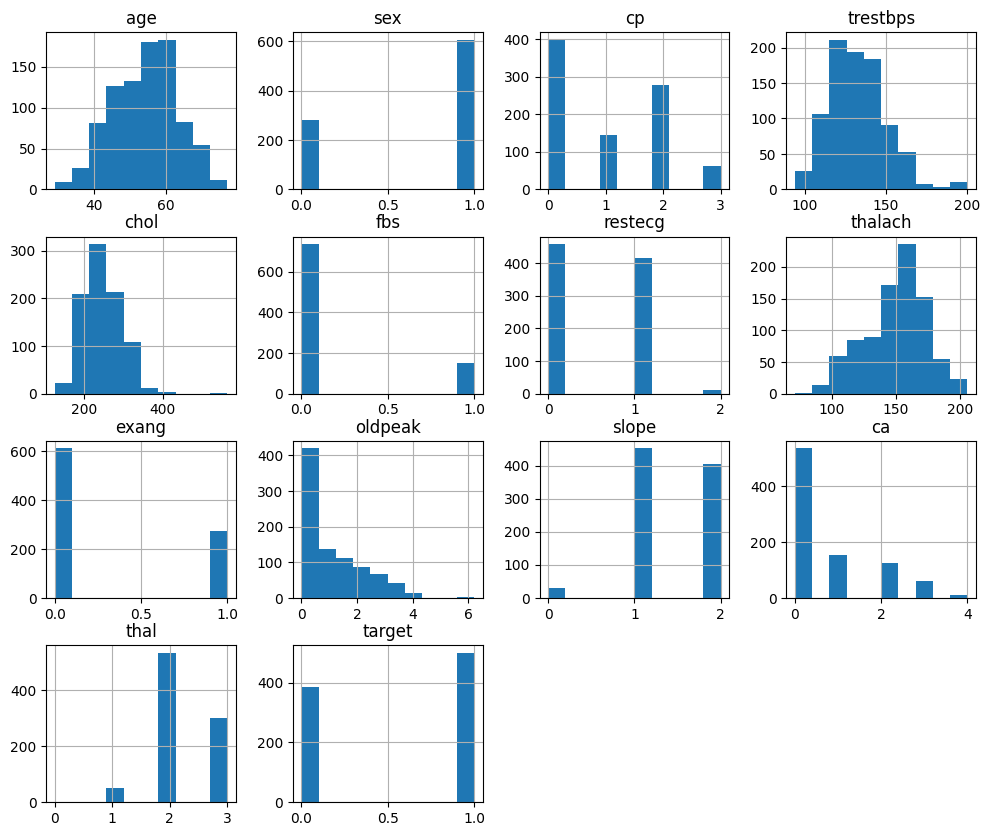

In [179]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
PATH = r"D:\ML\tuan2\heart.csv" # Path to your file

df = pd.read_csv(PATH)
#ToDo: Show histogram of dataframe
df.hist(df.columns, figsize=(12, 10))
plt.show()

In [180]:
# Kiểm tra lại các giá trị missing
display(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

## Data Analysis

<function matplotlib.pyplot.show(close=None, block=None)>

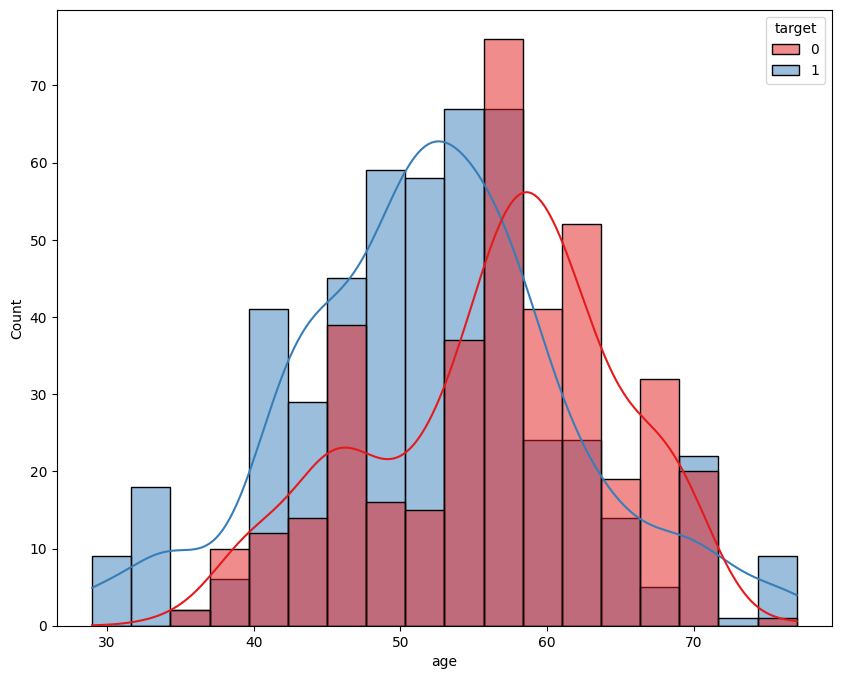

In [181]:
# Biểu đồ 1: Tuổi tác và bệnh tim
plt.figure(figsize=(10, 8))
sns.histplot(data=df, x='age', hue='target', kde=True, palette='Set1')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

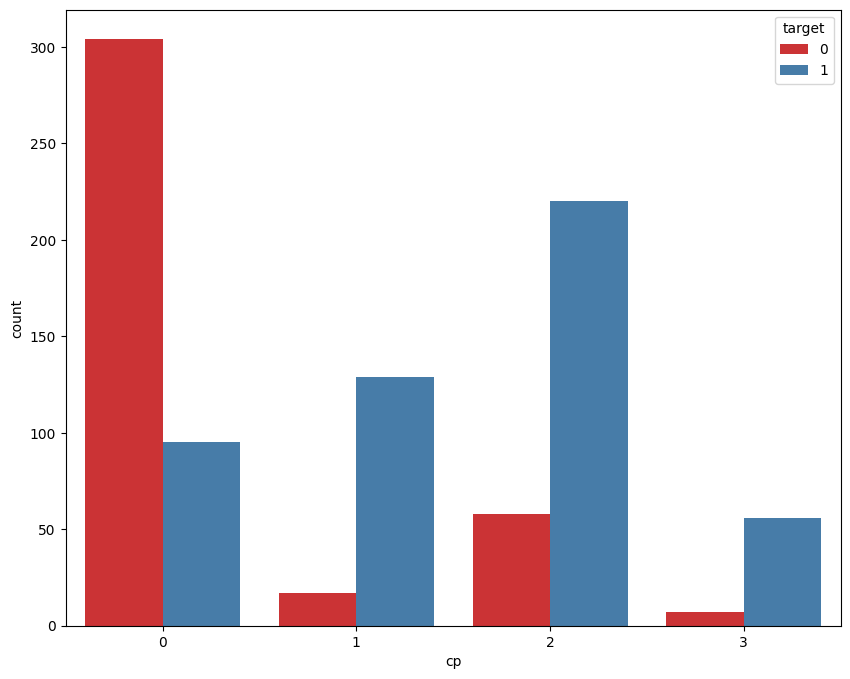

In [182]:
# Biểu đồ 2: Loại đau ngực và bệnh tim
plt.figure(figsize=(10, 8))
sns.countplot(data=df, x='cp', hue='target', palette='Set1')
plt.show

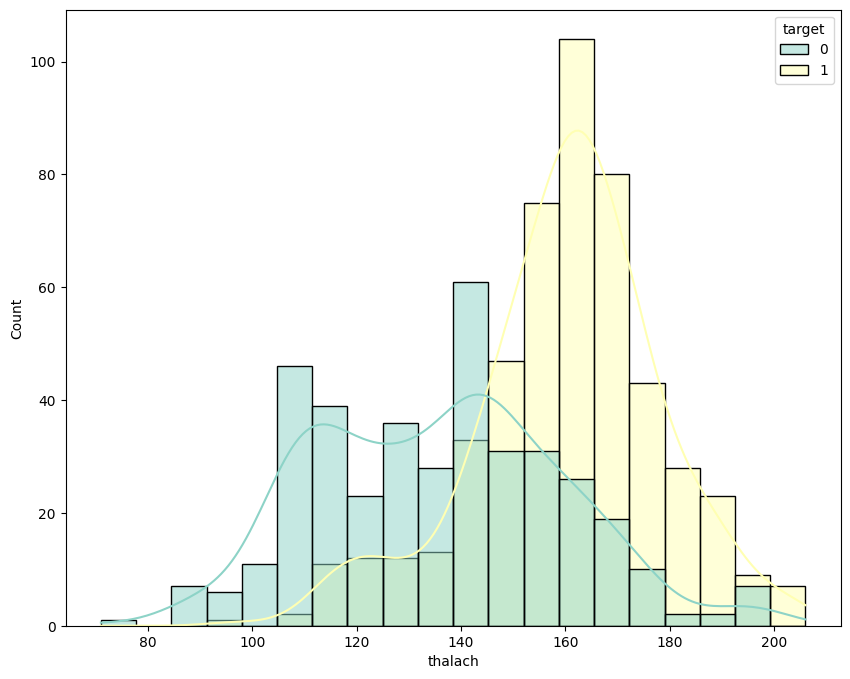

In [183]:
# Biểu đồ 3: Nhịp tim tối đa và bệnh tim
plt.figure(figsize=(10, 8))
sns.histplot(data=df, x='thalach', hue='target', kde=True, palette='Set3')
plt.show()

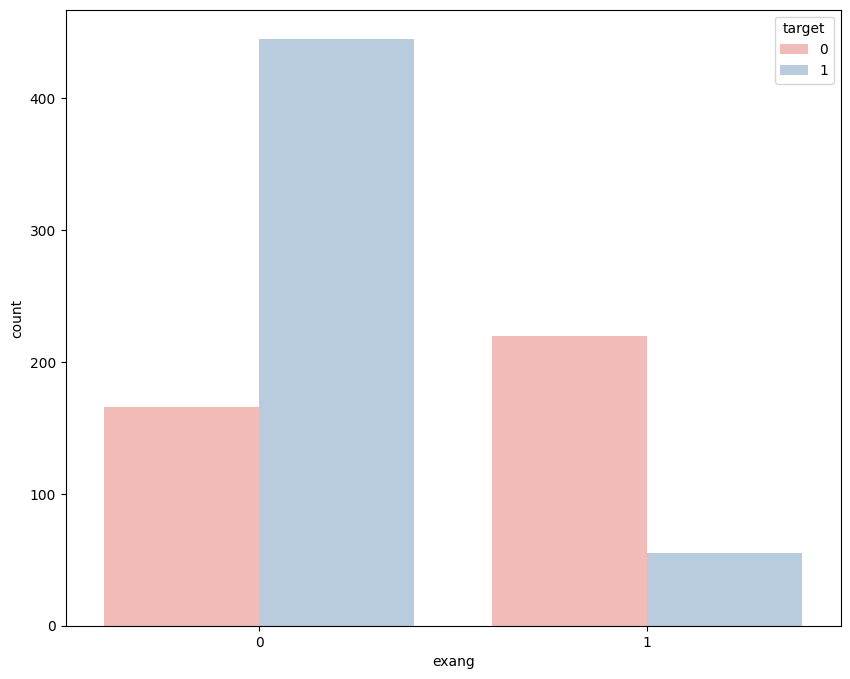

In [184]:
# Biểu đồ 4: Đau thắt ngực và bệnh tim
plt.figure(figsize=(10, 8))
sns.countplot(data=df, x='exang', hue='target', palette='Pastel1')
plt.show()

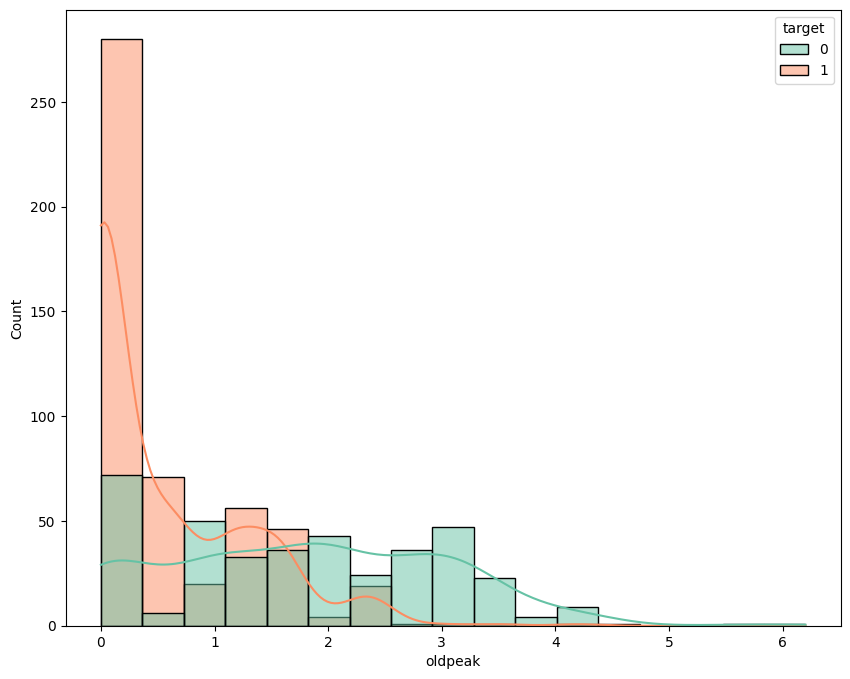

In [185]:
# Biểu đồ 4: Mức độ stress và bệnh tim
plt.figure(figsize=(10, 8))
sns.histplot(data=df, x='oldpeak', hue='target', kde=True, palette='Set2')
plt.show()

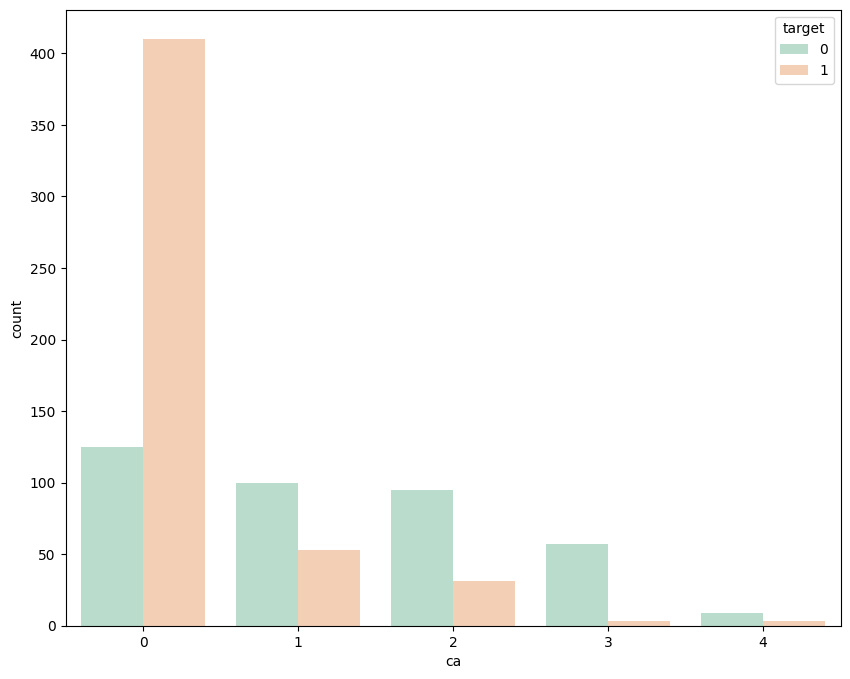

In [186]:
# Biểu đồ 5: Số lượng mạch máu chính và bệnh tim
plt.figure(figsize=(10, 8))
sns.countplot(data=df, x='ca', hue='target', palette='Pastel2')
plt.show()

## Preprocessing

In [187]:
def preprocessing_data(df):
    """
    Preprocess your data (eg. Drop null datapoints or fill missing data)
    :param df: pandas DataFrame
    :return: pandas DataFrame
    """
    # Todo: preprocess data
    # xóa dữ liệu lặp
    df = df.drop_duplicates()
    # xóa các dòng chứa NaN
    df = df.dropna()
    return df

In [188]:
df = preprocessing_data(df.copy())

## Feature Engineering

<Axes: >

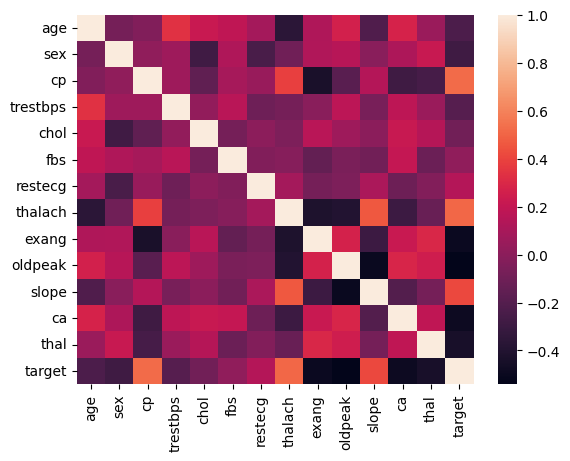

In [189]:
# Heatmap
import seaborn as sns

def apply_feature_engineering(df):
    """
    Apply all feature engineering to transform your data into number
    :param df: pandas DataFrame
    :return: pandas DataFrame
    """
    #tách tạm cột target ra
    temp = df['target']
    df1 = df.drop(['target'], axis=1)

    # Todo: Normalize your data
    scaler = StandardScaler()
    standard = scaler.fit_transform(df1.values)

    #tạo lại 1 df từ dữ liệu đã chuẩn hóa
    standard_df = pd.DataFrame(standard, columns=df1.columns, index=df1.index)

    #Ghép lại cột target vào df sau khi chuẩn hóa features
    df = pd.concat([standard_df, temp], axis=1)

    return df

df = apply_feature_engineering(df)
sns.heatmap(df.corr()) # Show heatmap after normalized data

In [190]:
def prepare_X_y(df):
    """
    Feature engineering and create X and y
    :param df: pandas dataframe
    :return: (X, y) output feature matrix (dataframe), target (series)
    """
    # Todo: Split data into X and y (using sklearn train_test_split). Return two dataframes
    y = df['target']# Todo: Select label
    X = df.drop(['target'], axis=1) # Todo: Select features
    return X, y

X, y = prepare_X_y(df)

# Apply machine learning model

## Train-test split

In [191]:
from sklearn.model_selection import train_test_split
RANDOM_STATE = 42
TRAIN_SIZE = 0.8

trainX, testX ,trainY, testY = train_test_split(X, y, train_size=TRAIN_SIZE, random_state=RANDOM_STATE)

## Build SK-learn model

In [192]:
from sklearn.metrics import classification_report
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def build_model(X, y):
    """
    Design your model and train it (including your best params)
    :param X: feature matrix
    :param y: target
    :return: a model
    """

    # Todo: Input your scaler and logistic model into pipeline
    #Nếu không tự chuẩn hóa thì sử dụng hàm dưới đây:
    # model = make_pipeline(StandardScaler(), LogisticRegression())

    #Nhưng ta đã chuẩn hóa ở trên rồi nên không cần thêm StandardScaler() nữa
    model = make_pipeline(LogisticRegression())

    # Todo: fit your model with X, y
    model.fit(X, y)

    return model

def calculate_performance(y_true, y_pred):
    """

    :param y_true: ground truth values
    :param y_pred: predictions
    :return:
    """
    # Todo: return your error value like accuracy, f1score, ...
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred) 
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print("precision", precision)
    print("recall", recall)
    print("accuracy", accuracy)
    print("F1", f1)

    # Todo: Only choose one of them as your score for the question 7
    main_score = f1
    return main_score

model = build_model(trainX, trainY)
# Compare on training dataset
pred = model.predict(testX)

In [193]:
calculate_performance(testY, pred)

precision 0.9626168224299065
recall 0.9716981132075472
accuracy 0.9606741573033708
F1 0.9671361502347418


0.9671361502347418

In [194]:
# thử với nhiều loại solver và penalty khác nhau
solver_list = ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
penalty_list = ['l1','l2', 'elasticnet', None]

best_score = 0
best_model = None

for soler in solver_list:
    for penalty in penalty_list:
        try:
            model = LogisticRegression(solver=soler, penalty=penalty)
            model.fit(X, y)

            predY = model.predict(testX)
            score = f1_score(testY, predY)

            if score > best_score:
                best_score = score
                best_model = [soler, penalty]
        except Exception:
            continue

print(best_score)
print(best_model)

0.9719626168224299
['lbfgs', None]


C:\Users\quanp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\quanp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\quanp

In [197]:
def get_conclusion():
    # Todo: Please return your answer, conclusion and opinion right here
    return """
    1. Main Metric: F1-Score. In medical datasets like heart disease, we need to balance Precision and Recall. Missing a sick patient is dangerous, but over-diagnosing is also bad. F1-score is the best overall metric.
    2. Model Params: I chose solver='lbfgs' and penalty='None' because it have a best f1 score.
    3. The best model achieved an f1 score of ~0.972.
    """

In [198]:
print(get_conclusion)

<function get_conclusion at 0x00000223EFF2ADE0>
